In [2]:
import os
import glob
import ctypes
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Détection et chargement de la DLL C++ générée par CLion
project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
dll_name = "ml_model.dll" if os.name == 'nt' else "libml_model.so"
search_pattern = os.path.join(project_root, "cmake-build-*", "**", dll_name)
found_dlls = glob.glob(search_pattern, recursive=True)

if not found_dlls:
    raise FileNotFoundError(f"Fichier '{dll_name}' introuvable sous {project_root}. Compilez le projet C++ dans CLion d'abord.")

lib_path = found_dlls[0]
print(f"[OK] DLL C++ chargée depuis : {lib_path}")

class PyLinearSoftmax:
    def __init__(self, num_features, num_classes):
        self.num_features = num_features
        self.num_classes = num_classes
        self.cpp_lib = ctypes.CDLL(lib_path)
        
        self.cpp_lib.LinearModel_create.argtypes = [ctypes.c_int, ctypes.c_int]
        self.cpp_lib.LinearModel_create.restype = ctypes.c_void_p
        self.cpp_lib.LinearModel_free.argtypes = [ctypes.c_void_p]
        self.cpp_lib.LinearModel_train.argtypes = [
            ctypes.c_void_p, ctypes.POINTER(ctypes.c_double), ctypes.POINTER(ctypes.c_int),
            ctypes.c_int, ctypes.c_int, ctypes.c_int, ctypes.c_double
        ]
        self.cpp_lib.LinearModel_predict.argtypes = [ctypes.c_void_p, ctypes.POINTER(ctypes.c_double), ctypes.c_int]
        self.cpp_lib.LinearModel_predict.restype = ctypes.c_int

        self.obj = self.cpp_lib.LinearModel_create(num_features, num_classes)

    def fit(self, X, y, epochs=300, lr=0.08):
        X_flat = np.ascontiguousarray(X, dtype=np.float64).flatten()
        y_flat = np.ascontiguousarray(y, dtype=np.int32)
        X_p = X_flat.ctypes.data_as(ctypes.POINTER(ctypes.c_double))
        y_p = y_flat.ctypes.data_as(ctypes.POINTER(ctypes.c_int))
        self.cpp_lib.LinearModel_train(self.obj, X_p, y_p, len(y), self.num_features, epochs, lr)

    def predict(self, X):
        preds = []
        for sample in X:
            feat = np.ascontiguousarray(sample, dtype=np.float64)
            feat_p = feat.ctypes.data_as(ctypes.POINTER(ctypes.c_double))
            preds.append(self.cpp_lib.LinearModel_predict(self.obj, feat_p, len(feat)))
        return np.array(preds)

    def __del__(self):
        if hasattr(self, 'obj') and self.obj:
            self.cpp_lib.LinearModel_free(self.obj)

[OK] DLL C++ chargée depuis : C:\Users\assia\CLionProjects\fleurs_classification\cmake-build-debug-visual-studio\ml_model.dll


In [3]:
def plot_decision_boundary(model, X, y, title, save_filename=None, is_transformed=False):
    plt.figure(figsize=(7, 5))
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200), np.linspace(y_min, y_max, 200))
    grid = np.c_[xx.ravel(), yy.ravel()]
    
    grid_input = np.c_[grid, grid[:, 0] * grid[:, 1]] if is_transformed else grid
        
    Z = model.predict(grid_input).reshape(xx.shape)
    
    plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', edgecolors='k', s=80)
    plt.title(title, fontsize=12)
    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.grid(True, linestyle='--', alpha=0.6)
    
    if save_filename:
        results_dir = os.path.join(project_root, "results")
        os.makedirs(results_dir, exist_ok=True)
        plt.savefig(os.path.join(results_dir, save_filename))
    plt.show()

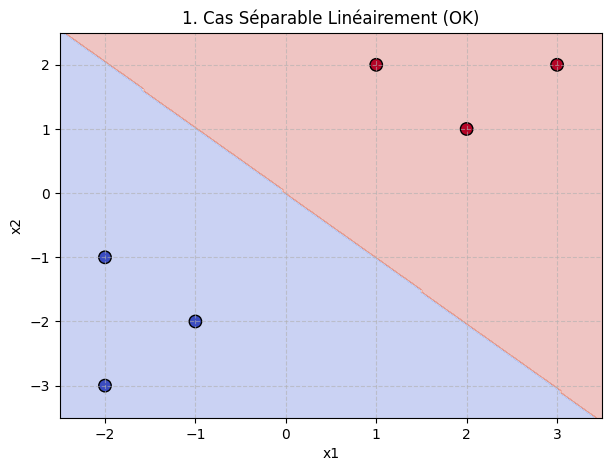

In [4]:
X_lin = np.array([[-2.0, -1.0], [-1.0, -2.0], [-2.0, -3.0], [1.0, 2.0], [2.0, 1.0], [3.0, 2.0]])
y_lin = np.array([0, 0, 0, 1, 1, 1])

model_lin = PyLinearSoftmax(num_features=2, num_classes=2)
model_lin.fit(X_lin, y_lin, epochs=300, lr=0.08)
plot_decision_boundary(model_lin, X_lin, y_lin, "1. Cas Séparable Linéairement (OK)", "1_linear_ok.png")

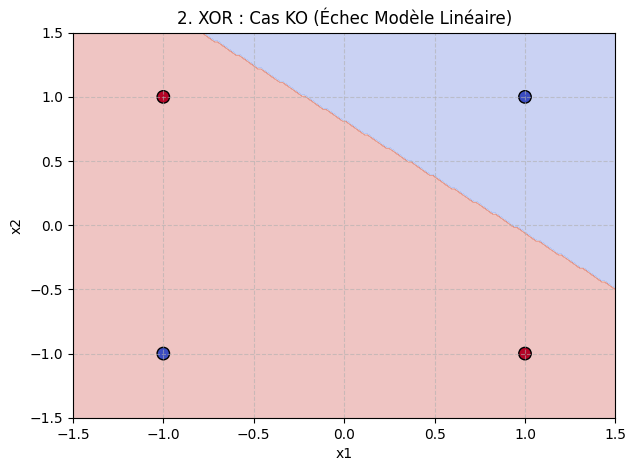

In [5]:
X_xor = np.array([[-1.0, -1.0], [1.0, 1.0], [-1.0, 1.0], [1.0, -1.0]])
y_xor = np.array([0, 0, 1, 1])

model_xor_ko = PyLinearSoftmax(num_features=2, num_classes=2)
model_xor_ko.fit(X_xor, y_xor, epochs=300, lr=0.08)
plot_decision_boundary(model_xor_ko, X_xor, y_xor, "2. XOR : Cas KO (Échec Modèle Linéaire)", "2_xor_ko.png")

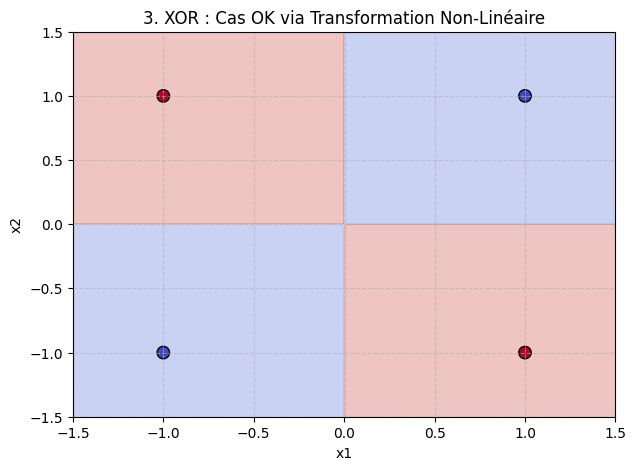

In [6]:
X_xor_trans = np.c_[X_xor, X_xor[:, 0] * X_xor[:, 1]]

model_xor_ok = PyLinearSoftmax(num_features=3, num_classes=2)
model_xor_ok.fit(X_xor_trans, y_xor, epochs=300, lr=0.08)
plot_decision_boundary(model_xor_ok, X_xor, y_xor, "3. XOR : Cas OK via Transformation Non-Linéaire", "3_xor_ok.png", is_transformed=True)

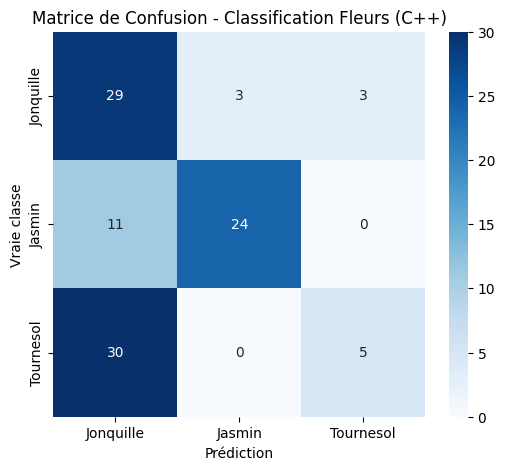

In [7]:
def extract_features_python(image_path):
    img = cv2.imread(image_path)
    if img is None:
        return None
    img = cv2.resize(img, (128, 128))
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    
    mean_bgr, std_bgr = cv2.meanStdDev(img)
    mean_hsv, std_hsv = cv2.meanStdDev(hsv)
    
    yellow_mask = cv2.inRange(hsv, (18, 70, 70), (42, 255, 255))
    edges = cv2.Canny(gray, 80, 160)
    
    num_pixels = 128.0 * 128.0
    yellow_ratio = cv2.countNonZero(yellow_mask) / num_pixels
    edge_ratio = cv2.countNonZero(edges) / num_pixels
    
    return [
        mean_bgr[0][0], mean_bgr[1][0], mean_bgr[2][0],
        std_bgr[0][0], std_bgr[1][0], std_bgr[2][0],
        mean_hsv[0][0], mean_hsv[1][0], mean_hsv[2][0],
        yellow_ratio, edge_ratio
    ]

def load_flower_dataset(folder_path):
    classes = ['jonquille', 'jasmin', 'tournesol']
    X, y = [], []
    for label_idx, class_name in enumerate(classes):
        class_dir = os.path.join(folder_path, class_name)
        if not os.path.exists(class_dir):
            continue
        for fname in os.listdir(class_dir):
            if fname.lower().endswith(('.png', '.jpg', '.jpeg')):
                feat = extract_features_python(os.path.join(class_dir, fname))
                if feat:
                    X.append(feat)
                    y.append(label_idx)
    return np.array(X), np.array(y)

train_dir = os.path.join(project_root, "data", "train")
test_dir = os.path.join(project_root, "data", "test")

if os.path.exists(train_dir) and os.path.exists(test_dir):
    X_train, y_train = load_flower_dataset(train_dir)
    X_test, y_test = load_flower_dataset(test_dir)

    if len(X_train) > 0 and len(X_test) > 0:
        flower_model = PyLinearSoftmax(num_features=11, num_classes=3)
        flower_model.fit(X_train, y_train, epochs=500, lr=0.03)
        y_pred = flower_model.predict(X_test)
        
        # Matrice de confusion
        cm = confusion_matrix(y_test, y_pred)
        plt.figure(figsize=(6, 5))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                    xticklabels=['Jonquille', 'Jasmin', 'Tournesol'], 
                    yticklabels=['Jonquille', 'Jasmin', 'Tournesol'])
        plt.title("Matrice de Confusion - Classification Fleurs (C++)")
        plt.xlabel("Prédiction")
        plt.ylabel("Vraie classe")
        
        results_dir = os.path.join(project_root, "results")
        os.makedirs(results_dir, exist_ok=True)
        plt.savefig(os.path.join(results_dir, "4_confusion_matrix.png"))
        plt.show()